# 3. When an order appears twice, which copy stays, and does Q1 then land on the books?

**Week 1, Wednesday. Chapter 3 of 6.** Chapter 2 fixed the identity rule, what makes two rows one order: an order is its `order_id`, which
the ERP, the enterprise resource planning system Finance books orders in, issues once per order.
Under that rule 15 orders appear twice in the export, 14 in Q1 and 1 in Q2. This chapter chooses
which copy of each pair stays and logs the other, which is the first step of the pass, the chain of
steps that turns the raw export into the clean file Anand's analyst reads.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Anand Iyer's analyst ties out to the rupee: she matches every figure to the books, Finance's own
record of Q1 at Rs 1,90,00,000, line by line, so a rupee's difference is a finding. A choice of copy
that loses one order's amount, Rs 1,790 on this file, turns the reconciliation into a finding
against the team.

**The questions on the way.**

1. Which copy of a pair could stay, and what does each choice do to Q1?
2. Which copy stays when the two copies differ?
3. What is Q1 once the rule runs?
4. If Q1 ties to the books, is the pass right?
5. Which rows carry the rupees set aside?
6. Does a dictionary keyed by id keep the same orders?

**The need.** The metric is Q1 revenue to the rupee, against the books' Rs 1,90,00,000. The ERP
team stitched the export from two extracts, two separate pulls of rows out of the ERP, during the Q1
migration, the move of the order data from one system to another, and fifteen orders appear twice.
For thirteen the two copies are identical and either may stay; for two they disagree, and the
choice moves Q1 and a date.

**Who else faces it.** India's GST system writes an identity rule into law for invoices between businesses. The Invoice Registration Portal rejects an invoice already reported under the same supplier GSTIN (the seller's GST registration number), invoice number, document type and financial year, the fields it also hashes into the invoice's reference number (GSTN e-invoice FAQ, version 1.4, checked 30 Sep 2026). Since 1 August 2023 the rule binds sellers above Rs 5 crore of aggregate turnover on their invoices to registered businesses, with some sectors, such as banks and insurers, exempt (Notification 10/2023-Central Tax and the same FAQ, both checked 30 Sep 2026). Those are the invoices a seller like Kalpa writes in its Business segment, its sales to companies, where every order runs to lakhs.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell loads the shared helper `kit`, chapter 1's reading tools and `identity_rule()`,
the rule this chapter argues for, defined here so the cells below can run it. `read_orders()` reads
each row into a dictionary of text and keeps its file line, and `convert()` turns an amount into
rupees or says why it could not.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

raw = read_orders()
print(len(raw), "rows read")

201 rows read


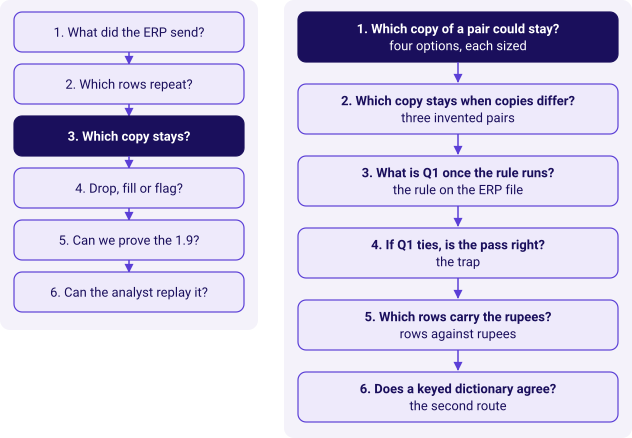

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=2, show=False),
    kit.vflow(["1. Which copy of a pair could stay?\nfour options, each sized", "2. Which copy stays when copies differ?\nthree invented pairs", "3. What is Q1 once the rule runs?\nthe rule on the ERP file", "4. If Q1 ties, is the pass right?\nthe trap", "5. Which rows carry the rupees?\nrows against rupees", "6. Does a keyed dictionary agree?\nthe second route"], lit=0, show=False),
)

## 1. Which copy of a pair could stay, and what does each choice do to Q1?

| Option | Which copy stays | What it assumes |
|---|---|---|
| a) The first in the file | the row from the first extract | the first extract is the original |
| b) The last in the file | the row from the second extract | the second extract corrected the first |
| c) The copy that validates, then the first | a copy whose amount converts; the first if both do | a value beats no value; otherwise keep the original |
| d) Keep both, escalate every pair | none until the ERP team answers | nobody inside Kalpa can decide |

**Predict before you run.** Which options land Q1 on the books to the rupee? a) a only; b) b and c;
c) c only; d) all four.

option,Q1,against the books,unreadable orders kept,questions to the ERP team
a) first,"Rs 1,89,98,210","-Rs 1,790",1,none
b) last,"Rs 1,90,00,000",Rs 0,0,none
c) validates,"Rs 1,90,00,000",Rs 0,0,none
d) escalate all,open,open,0,"15 pairs, days of waiting"


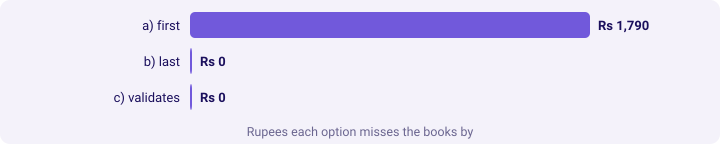

In [3]:
def keep(rows, how):
    kept = {}
    for r in rows:
        k = r["order_id"]
        if k not in kept or how == "last":
            kept[k] = r
        elif how == "validates" and convert(kept[k]["amount"])[0] is None and convert(r["amount"])[0] is not None:
            kept[k] = r
    return list(kept.values())

options = {"a) first": keep(raw, "first"), "b) last": keep(raw, "last"), "c) validates": keep(raw, "validates")}
rows_out = [(name, kit.rupees(Q(k, "Q1")), kit.rupees(Q(k, "Q1") - BOOKS_Q1),
             sum(1 for r in k if convert(r["amount"])[0] is None), "none") for name, k in options.items()]
rows_out.append(("d) escalate all", "open", "open", 0, "15 pairs, days of waiting"))
kit.table(["option", "Q1", "against the books", "unreadable orders kept", "questions to the ERP team"], rows_out,
          caption="Each option sized on the ERP file")
kit.bars([(n, abs(Q(k, "Q1") - BOOKS_Q1)) for n, k in options.items()], fmt=kit.rupees,
         title="Rupees each option misses the books by")

**What happened.** The answer is b. The first copy keeps a row whose amount cannot be read and lands
Rs 1,790 short. The last copy lands on the books, and so does the copy that validates. Escalating
everything leaves Q1 open for as long as the ERP team takes to answer 15 questions, 13 of them about
pairs whose copies are identical.

**The best-fit call: c, and escalate only a pair whose valid copies disagree.** The last copy lands
on the books here only because of the order in which the migration appended its rows, and no rule
promises that order next time. **The fact that would change it:** the ERP team saying the second
extract was a corrected re-run. Then b is the rule, and it is right for a reason.

## 2. Which copy stays when the two copies differ?

Three invented pairs show the kinds of pair a rule has to handle. Pair A is an exact copy. In pair B
one copy's amount does not convert and the other's does. In pair C both convert and the two
disagree on the date.

**Predict before you run.** For pair C, which copy should stay? a) the first, logged, and the date
asked of the ERP team; b) the later date; c) neither; d) both.

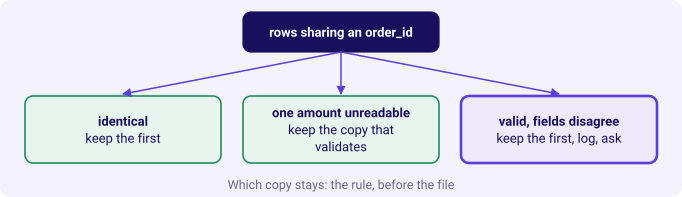

order,kept line,set aside,reason
INV-11,12,90,second copy of the order
INV-12,95,20,copy whose amount does not convert; its twin carries the value
INV-13,40,99,second copy of the order; differs on order_date


In [4]:
pairs = [
    {"order_id": "INV-11", "quarter": "Q1", "segment": "Retail-Core", "order_date": "2026-05-02", "amount": "1800", "line": 12},
    {"order_id": "INV-11", "quarter": "Q1", "segment": "Retail-Core", "order_date": "2026-05-02", "amount": "1800", "line": 90},
    {"order_id": "INV-12", "quarter": "Q1", "segment": "Retail-Plus", "order_date": "2026-05-14", "amount": "n/a", "line": 20},
    {"order_id": "INV-12", "quarter": "Q1", "segment": "Retail-Plus", "order_date": "2026-05-14", "amount": "2600", "line": 95},
    {"order_id": "INV-13", "quarter": "Q2", "segment": "Retail-Plus", "order_date": "2026-08-21", "amount": "3100", "line": 40},
    {"order_id": "INV-13", "quarter": "Q2", "segment": "Retail-Plus", "order_date": "2026-07-30", "amount": "3100", "line": 99},
]   # invented
kept_pairs, log_pairs = identity_rule(pairs)
kit.tree({"label": "rows sharing an order_id", "kind": "lit", "branches": [
    ("", {"label": "identical\nkeep the first", "kind": "good"}),
    ("", {"label": "one amount unreadable\nkeep the copy that validates", "kind": "good"}),
    ("", {"label": "valid, fields disagree\nkeep the first, log, ask", "kind": "known"})]},
    title="Which copy stays: the rule, before the file")
kit.table(["order", "kept line", "set aside", "reason"],
          [(e["order_id"], e["kept_line"], e["line"], e["reason"]) for e in log_pairs],
          caption="Invented pairs: one row per order, and a reason for every row set aside")
kit.check("the unreadable copy of INV-12 is the one set aside", [e["line"] for e in log_pairs if e["order_id"] == "INV-12"] == [20])

**What happened.** The answer is a. Keeping the first copy of pair B would keep the one that cannot
be summed, so the rule prefers the copy that validates. In pair C both copies are valid and no rule
inside the file can say which date is true, so the rule keeps the first extract's row, logs the
disagreement and turns the date into a written question for the ERP team.

## 3. What is Q1 once the rule runs?

**Predict before you run.** After the identity rule, Q1 is? a) Rs 2,09,98,210; b) Rs 1,89,98,210;
c) Rs 1,90,00,000; d) Rs 2,00,00,000.

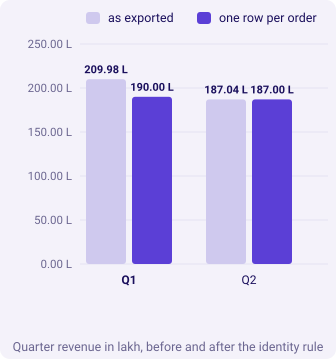

In [5]:
kept, set_aside = identity_rule(raw)
kit.columns(["Q1", "Q2"], [("as exported", [Q(raw, "Q1") / 1e5, Q(raw, "Q2") / 1e5]),
                           ("one row per order", [Q(kept, "Q1") / 1e5, Q(kept, "Q2") / 1e5])],
            fmt=lambda v: f"{v:,.2f} L", lit=(0,), title="Quarter revenue in lakh, before and after the identity rule")
kit.stats([(str(len(kept)), "orders kept", "one row per order_id"),
           (str(len(set_aside)), "rows set aside", "each with a reason"),
           (kit.rupees(Q(kept, "Q1")), "Q1", "the books say Rs 1,90,00,000")])
kit.check("186 orders kept and 15 rows set aside", (len(kept), len(set_aside)) == (186, 15))
kit.check("Q1 lands on the books", Q(kept, "Q1") == BOOKS_Q1, kit.rupees(Q(kept, "Q1")))
kit.check("no kept order has an amount that fails", all(convert(r["amount"])[0] is not None for r in kept))

**What happened.** The answer is c. Q1 moves from Rs 2,09,98,210 to Rs 1,90,00,000, Finance's 1.9
crore to the rupee, and Q2 from Rs 1,87,03,710 to Rs 1,87,00,000. Two of the 15 rows set aside
carry a reason longer than "second copy of the order", and those two are where the rule made a
choice.

**Your turn.** In the empty cell, print them:
`[(e["line"], e["order_id"], e["reason"]) for e in set_aside if e["reason"] != "second copy of the order"]`.
For each, say what the reason tells you: where the one amount chapter 1 could not read went, and
which field a pair's copies disagree on. Then write the question you would send the ERP team.

## 4. If Q1 ties to the books, is the pass right?

Chapter 2 found that comparing every field except the file line flags 13 rows as copies. A hurried
analyst dedupes that way, removing every row that repeats another on those fields, sees Q1 land on
the books, and stops.

**The plausible wrong answer.**

In [6]:
seen, exact = set(), []
for r in raw:
    k = tuple(sorted((f, v) for f, v in r.items() if f != "line"))
    if k not in seen:
        seen.add(k)
        exact.append(r)
kit.stats([(kit.rupees(Q(exact, "Q1")), "Q1", "equal to the books, to the rupee"),
           (str(len(exact)), "orders in the clean file", "reported as orders"),
           (kit.rupees(Q(exact, "Q2")), "Q2", "sent on to Marketing")],
          caption="The whole record less the line, as it would be reported")

**Why it is wrong.** Q1 ties because the two pairs this pass misses happen to cost Q1 nothing: one
copy's amount cannot be read, so it adds nothing to the sum. The file still holds 188 rows for 186
orders. One Q2 order is counted twice, so Q2 is Rs 3,710 high and the Q2 order count for
Retail-Plus, Kalpa's paid membership tier, is one too many, and an order with an unreadable amount
sits in the clean file as an order. A
rupee tie on one quarter proves that quarter's rupees; it cannot prove the rows. The check is the
one chapter 2 taught: rows kept against distinct ids.

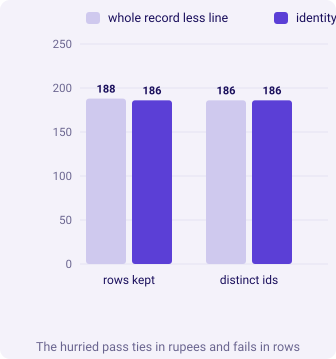

In [7]:
kit.check("the hurried pass keeps more rows than there are orders", len(exact) > len({r["order_id"] for r in exact}),
          f"{len(exact)} rows, {len({r['order_id'] for r in exact})} ids")
kit.check("the hurried Q2 is Rs 3,710 above one row per order", Q(exact, "Q2") - Q(kept, "Q2") == 3710)
kit.columns(["rows kept", "distinct ids"], [("whole record less line", [len(exact), len({r["order_id"] for r in exact})]),
                                           ("identity rule", [len(kept), len({r["order_id"] for r in kept})])],
            title="The hurried pass ties in rupees and fails in rows")

**The fix, and what changed.** The identity rule on `order_id`, preferring the copy that validates:
186 rows for 186 orders, Q2 down Rs 3,710 to Rs 1,87,00,000, the unreadable row set aside with its
reason, and one date written up as a question for the ERP team.

## 5. Which rows carry the rupees set aside?

**Predict before you run.** Of the Rs 19,98,210 the rule removed from Q1, what share sits in
Business rows? a) about a sixth, since they are 2 of 14; b) about half; c) nearly all; d) none.

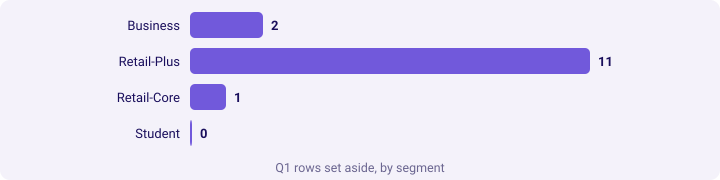

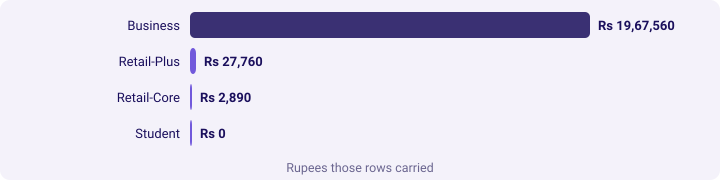

In [8]:
segs = ["Business", "Retail-Plus", "Retail-Core", "Student"]
q1_aside = [e for e in set_aside if e["quarter"] == "Q1"]
rows_removed = [sum(1 for e in q1_aside if e["segment"] == s) for s in segs]
rupees_removed = [sum(convert(e["amount"])[0] or 0 for e in q1_aside if e["segment"] == s) for s in segs]
kit.bars(list(zip(segs, rows_removed)), title="Q1 rows set aside, by segment")
kit.bars(list(zip(segs, rupees_removed)), fmt=kit.rupees, lit=(0,), title="Rupees those rows carried")
share = rupees_removed[0] / sum(rupees_removed)
kit.check("Business rows carry over 95 percent of the rupees removed", share > 0.95, f"{share:.1%}")
kit.check("Retail-Plus carries the most rows removed", rows_removed[1] == max(rows_removed), f"{rows_removed[1]} of {len(q1_aside)}")

**What happened.** The answer is c. Two Business rows carry Rs 19,67,560 of Rs 19,98,210, about 98
percent, and eleven Retail-Plus rows carry Rs 27,760. The split settles two different questions.
Anand's gap is two corporate orders counted twice. Tuesday's finding, that orders per customer in
Retail-Plus fell 49 percent from Q1 to Q2, is a different matter:
most extra rows sit in Retail-Plus in Q1, the segment and quarter Tuesday compared, so that fall was
measured on inflated Q1 counts. Chapter 5 recomputes it.

## 6. Does a dictionary keyed by id keep the same orders?

A dictionary keeps one value per key, so building one from the valid rows is an identity rule in a
line, and a second route to the same orders. It keeps the last valid copy, and it logs nothing.

In [9]:
by_id = {r["order_id"]: r for r in raw if convert(r["amount"])[0] is not None}
same_ids = set(by_id) == {r["order_id"] for r in kept}
same_amounts = all(convert(by_id[r["order_id"]]["amount"])[0] == convert(r["amount"])[0] for r in kept)
kit.table(["route", "orders", "Q1", "Q2", "rows logged"],
          [("identity_rule", len(kept), kit.rupees(Q(kept, "Q1")), kit.rupees(Q(kept, "Q2")), len(set_aside)),
           ("a dict keyed by id", len(by_id), kit.rupees(Q(by_id.values(), "Q1")), kit.rupees(Q(by_id.values(), "Q2")), 0)])
kit.check("both routes keep the same 186 orders at the same amounts", same_ids and same_amounts)

route,orders,Q1,Q2,rows logged
identity_rule,186,"Rs 1,90,00,000","Rs 1,87,00,000",15
a dict keyed by id,186,"Rs 1,90,00,000","Rs 1,87,00,000",0


**When to switch.** The dictionary is the fast check that the rule's totals are right. It cannot be
the pass itself, since it chooses silently and leaves Anand's analyst nothing to audit.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "I want an identity rule, a preference for the copy that validates and a
> reason on every row you set aside. When Q1 ties to the books, check the rows before you celebrate."

### In the interview: two copies of an order disagree, so do you keep the first, the last or the one that validates?

**[D] Design. Two copies of an order disagree: first copy, last copy or the copy that validates?**
"The copy whose fields validate; if both do, the one the business calls the original, the first
extract here, and I log the disagreement and ask the owner of the source. I size the choice first:
keeping the first copy would have cost Rs 1,790 against the books, and keeping the last landed on
the books only because of the order the migration appended its rows. If the ERP team told me the
second extract was a corrected re-run, I would switch to the last copy and write that down as the
reason."

### Depth: when a rule keeps one record of several, which one survives, and on what assumption?

Every "keep one" rule is a choice about which record survives, and each survivor rule carries an
assumption about the source: first means original, last means corrected, most complete means the
fields are independent. Master-data tools call this the survivorship rule, and they ask for it to
be written down per field.

## So which copy stays, and does Q1 then land on the books?

1. Keeping the first copy of each pair misses the books by Rs 1,790, keeping the last lands on them
   by the luck of file order, and keeping the copy that validates lands on them for a reason.
2. When the two copies differ, the one whose amount converts stays; when both convert and disagree,
   the first stays, logged, with a question for the ERP team.
3. Once the rule runs, Q1 is Rs 1,90,00,000, the books to the rupee, with 186 orders kept and 15
   rows set aside.
4. A Q1 that ties to the books does not prove the pass by itself: the whole record less the line
   ties Q1 and keeps 188 rows for 186 orders, with Q2 Rs 3,710 high.
5. Two Business rows carry Rs 19,67,560 of the Rs 19,98,210 set aside, 98.5 percent, and eleven
   Retail-Plus rows carry Rs 27,760.
6. A dictionary keyed by id keeps the same 186 orders at the same amounts, and it logs nothing.

The copy whose amount converts stays, and the first when both do. The rule keeps 186 orders and
sets 15 rows aside with a reason each; Q1 is then Rs 1,90,00,000, the books to the rupee, and Q2 is
Rs 1,87,00,000.

In [10]:
kit.check_summary()
print("Next, chapter 4: what should the pass do with a value that is missing or cannot be read, "
      "so that no decision invents or deletes a fact?")

Next, chapter 4: what should the pass do with a value that is missing or cannot be read, so that no decision invents or deletes a fact?
